## Linear Interpolation VS KNN 

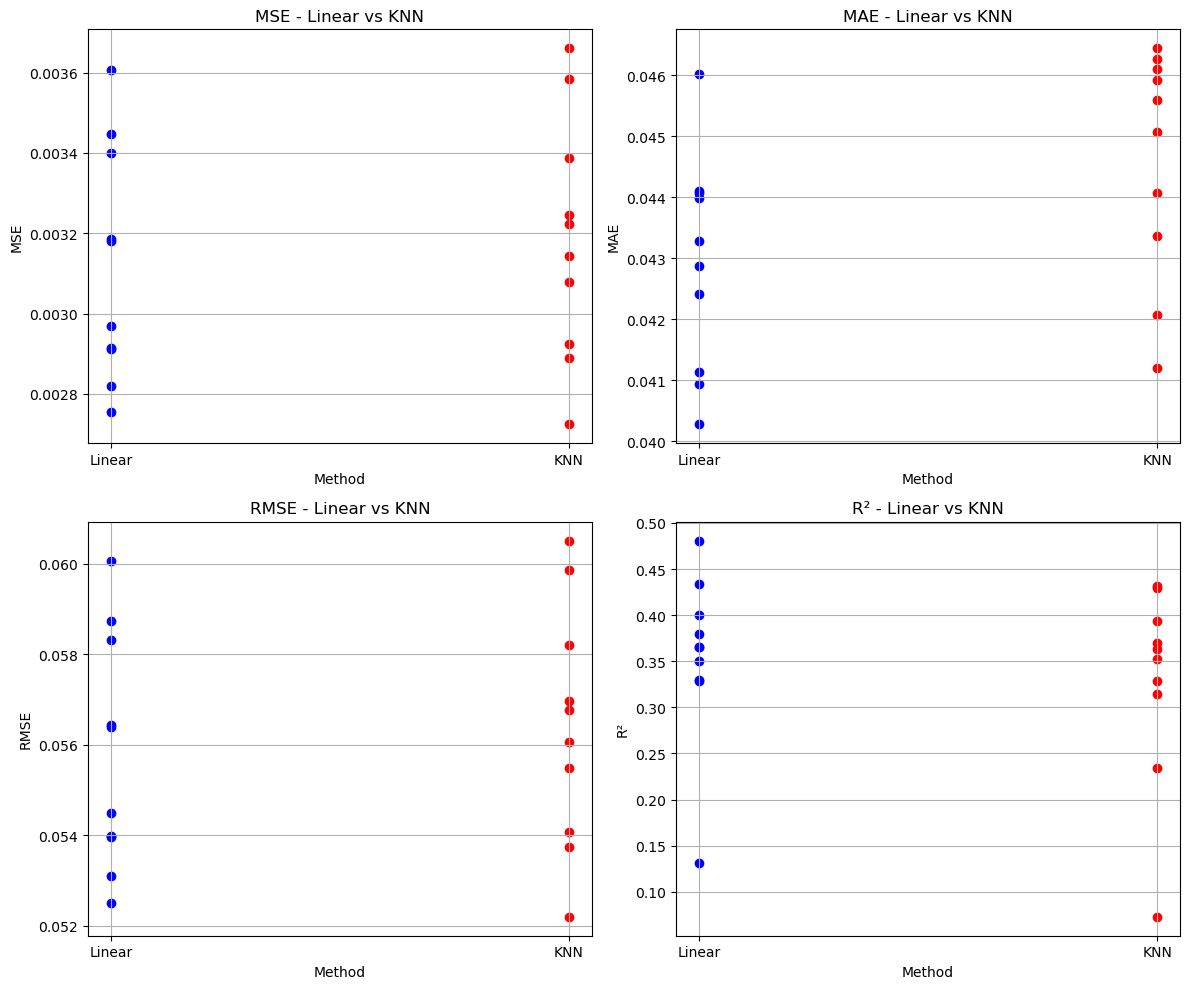

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from scipy.interpolate import griddata
from math import sqrt
import time

# Load the data
file_path = '/Users/inayahkhan/Desktop/Group_Diss_Code/'  # Update this path
coords = np.load(file_path + 'coords.npy')
band_powers = np.load(file_path + 'band_powers.npy', allow_pickle=True).item()

# Choose which frequency band to evaluate
band = 'Delta'
values = np.array(band_powers[band])

# Define Linear Interpolation Function
def interpolate_linear(coords, values, new_coords, timing=False):
    start_time = time.time()
    predicted_values = griddata(coords, values, new_coords, method='linear')
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# Define KNN Interpolation Function
def interpolate_knn(coords, values, new_coords, timing=False):
    start_time = time.time()
    model = KNeighborsRegressor(n_neighbors=5)
    model.fit(coords, values)
    predicted_values = model.predict(new_coords)
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# Define Metric Calculation Function
def calculate_metrics(pred_values, test_values):
    scores = {
        'MSE': mean_squared_error(test_values, pred_values),
        'MAE': mean_absolute_error(test_values, pred_values),
        'RMSE': sqrt(mean_squared_error(test_values, pred_values)),
        'R²': r2_score(test_values, pred_values)
    }
    return scores

# Set up cross-validation
num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialise arrays to store results
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
linear_results = np.zeros((num_folds, len(metrics)))
knn_results = np.zeros((num_folds, len(metrics)))

# Cross-validation for Linear Interpolation
for i, (train_index, test_index) in enumerate(kf.split(coords)):
    train_coords, test_coords = coords[train_index], coords[test_index]
    train_values, test_values = values[train_index], values[test_index]
    
    pred_values = interpolate_linear(train_coords, train_values, test_coords)
    valid_indices = ~np.isnan(pred_values)
    pred_values = pred_values[valid_indices]
    test_values = test_values[valid_indices]
    
    if len(pred_values) > 0:
        scores = calculate_metrics(pred_values, test_values)
        linear_results[i] = [scores[m] for m in metrics]

# Cross-validation for KNN Interpolation
for i, (train_index, test_index) in enumerate(kf.split(coords)):
    train_coords, test_coords = coords[train_index], coords[test_index]
    train_values, test_values = values[train_index], values[test_index]
    
    pred_values = interpolate_knn(train_coords, train_values, test_coords)
    valid_indices = ~np.isnan(pred_values)
    pred_values = pred_values[valid_indices]
    test_values = test_values[valid_indices]
    
    if len(pred_values) > 0:
        scores = calculate_metrics(pred_values, test_values)
        knn_results[i] = [scores[m] for m in metrics]

# Create a 2x2 grid for the scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    axes[i].scatter(['Linear'] * num_folds, linear_results[:, i], label='Linear', color='blue')
    axes[i].scatter(['KNN'] * num_folds, knn_results[:, i], label='KNN', color='red')

    axes[i].set_title(f'{metric} - Linear vs KNN')
    axes[i].set_xlabel('Method')
    axes[i].set_ylabel(metric)
    axes[i].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


## Performance Comparison (Linear vs KNN)

##### **MSE (Mean Squared Error)**
- Lower is better → KNN shows slightly lower and more consistent MSE.  
**KNN slightly better** for accuracy and consistency.  

##### **MAE (Mean Absolute Error)**
- Lower is better → KNN generally has lower MAE with less spread.  
**KNN better** for absolute accuracy.  

##### **RMSE (Root Mean Squared Error)**
- Lower is better → KNN shows slightly lower RMSE, indicating fewer large errors.
**KNN better** at handling large errors.  

##### **R² (Coefficient of Determination)**
- Higher is better → KNN has higher and more consistent R², indicating a better overall fit.  
**KNN better** at explaining variance.  

##### **Conclusion:**  
- KNN is **slightly better** overall — more accurate, consistent, and better fit — but the difference is small. Both methods perform similarly well.


## Linear VS KNN VS Spline (smoothness 0.2)

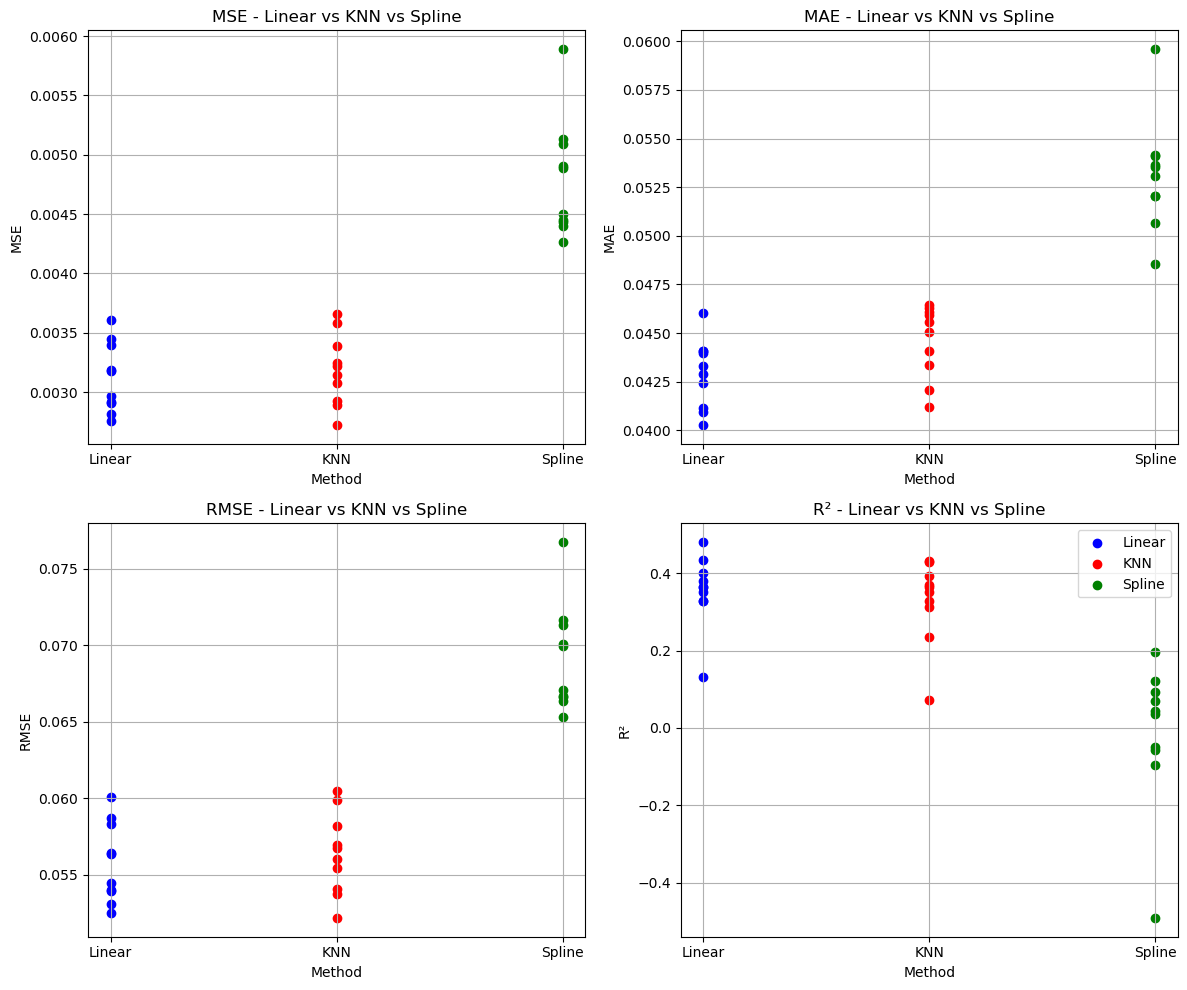


Cross-Validation Results (Average):
        Linear       KNN    Spline
MSE   0.003119  0.003186  0.004796
MAE   0.042909  0.044607  0.053134
RMSE  0.055793  0.056384  0.069175
R²    0.356560  0.329083 -0.013177


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from scipy.interpolate import griddata, Rbf
from math import sqrt
import time

# Load the data
file_path = '/Users/inayahkhan/Desktop/Group_Diss_Code/'  # Update this path
coords = np.load(file_path + 'coords.npy')
band_powers = np.load(file_path + 'band_powers.npy', allow_pickle=True).item()

# Choose which frequency band to evaluate
band = 'Delta'
values = np.array(band_powers[band])

# Define Linear Interpolation Function
def interpolate_linear(coords, values, new_coords, timing=False):
    start_time = time.time()
    predicted_values = griddata(coords, values, new_coords, method='linear')
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# Define KNN Interpolation Function
def interpolate_knn(coords, values, new_coords, timing=False):
    start_time = time.time()
    model = KNeighborsRegressor(n_neighbors=5)
    model.fit(coords, values)
    predicted_values = model.predict(new_coords)
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# Define Spline Interpolation Function
def interpolate_spline(coords, values, new_coords, timing=False, smooth=0.2):
    start_time = time.time()
    interpolator = Rbf(
        coords[:, 0], coords[:, 1], coords[:, 2], values, function='cubic', smooth=smooth
    )
    predicted_values = interpolator(new_coords[:, 0], new_coords[:, 1], new_coords[:, 2])
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# Define Metric Calculation Function
def calculate_metrics(pred_values, test_values):
    scores = {
        'MSE': mean_squared_error(test_values, pred_values),
        'MAE': mean_absolute_error(test_values, pred_values),
        'RMSE': sqrt(mean_squared_error(test_values, pred_values)),
        'R²': r2_score(test_values, pred_values)
    }
    return scores

# Set up cross-validation
num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialise arrays to store results
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
linear_results = np.zeros((num_folds, len(metrics)))
knn_results = np.zeros((num_folds, len(metrics)))
spline_results = np.zeros((num_folds, len(metrics)))

# Cross-validation for Linear Interpolation
for i, (train_index, test_index) in enumerate(kf.split(coords)):
    train_coords, test_coords = coords[train_index], coords[test_index]
    train_values, test_values = values[train_index], values[test_index]
    
    pred_values = interpolate_linear(train_coords, train_values, test_coords)
    valid_indices = ~np.isnan(pred_values)
    pred_values = pred_values[valid_indices]
    test_values = test_values[valid_indices]
    
    if len(pred_values) > 0:
        scores = calculate_metrics(pred_values, test_values)
        linear_results[i] = [scores[m] for m in metrics]

# Cross-validation for KNN Interpolation
for i, (train_index, test_index) in enumerate(kf.split(coords)):
    train_coords, test_coords = coords[train_index], coords[test_index]
    train_values, test_values = values[train_index], values[test_index]
    
    pred_values = interpolate_knn(train_coords, train_values, test_coords)
    valid_indices = ~np.isnan(pred_values)
    pred_values = pred_values[valid_indices]
    test_values = test_values[valid_indices]
    
    if len(pred_values) > 0:
        scores = calculate_metrics(pred_values, test_values)
        knn_results[i] = [scores[m] for m in metrics]

# Cross-validation for Spline Interpolation
for i, (train_index, test_index) in enumerate(kf.split(coords)):
    train_coords, test_coords = coords[train_index], coords[test_index]
    train_values, test_values = values[train_index], values[test_index]
    
    pred_values = interpolate_spline(train_coords, train_values, test_coords, smooth=0.2)
    valid_indices = ~np.isnan(pred_values)
    pred_values = pred_values[valid_indices]
    test_values = test_values[valid_indices]
    
    if len(pred_values) > 0:
        scores = calculate_metrics(pred_values, test_values)
        spline_results[i] = [scores[m] for m in metrics]

# Create a 2x2 grid for the scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    axes[i].scatter(['Linear'] * num_folds, linear_results[:, i], label='Linear', color='blue')
    axes[i].scatter(['KNN'] * num_folds, knn_results[:, i], label='KNN', color='red')
    axes[i].scatter(['Spline'] * num_folds, spline_results[:, i], label='Spline', color='green')

    axes[i].set_title(f'{metric} - Linear vs KNN vs Spline')
    axes[i].set_xlabel('Method')
    axes[i].set_ylabel(metric)
    axes[i].grid(True)

# Adjust layout
plt.tight_layout()
plt.legend()
plt.show()

# Create a summary DataFrame for all methods
df_linear = pd.DataFrame(linear_results, columns=metrics)
df_knn = pd.DataFrame(knn_results, columns=metrics)
df_spline = pd.DataFrame(spline_results, columns=metrics)

df_results = pd.concat([
    df_linear.mean().rename('Linear'),
    df_knn.mean().rename('KNN'),
    df_spline.mean().rename('Spline')
], axis=1)

print("\nCross-Validation Results (Average):")
print(df_results)

### Splining 
#### 0 vs 0.2 vs 0.5 


Running cross-validation for smoothness=0...


/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=1.20186e-38): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)
/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=1.72177e-35): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)
/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=4.14481e-37): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)
/Users/inayahkhan/Library/jupyterlab-desktop/jlab_server/lib/python3.8/site-packages/scipy/interpolate/_rbf.py:267: LinAlgWarning: Ill-conditioned matrix (rcond=4.70429e-38): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)
/Users/i


Running cross-validation for smoothness=0.2...

Running cross-validation for smoothness=0.5...


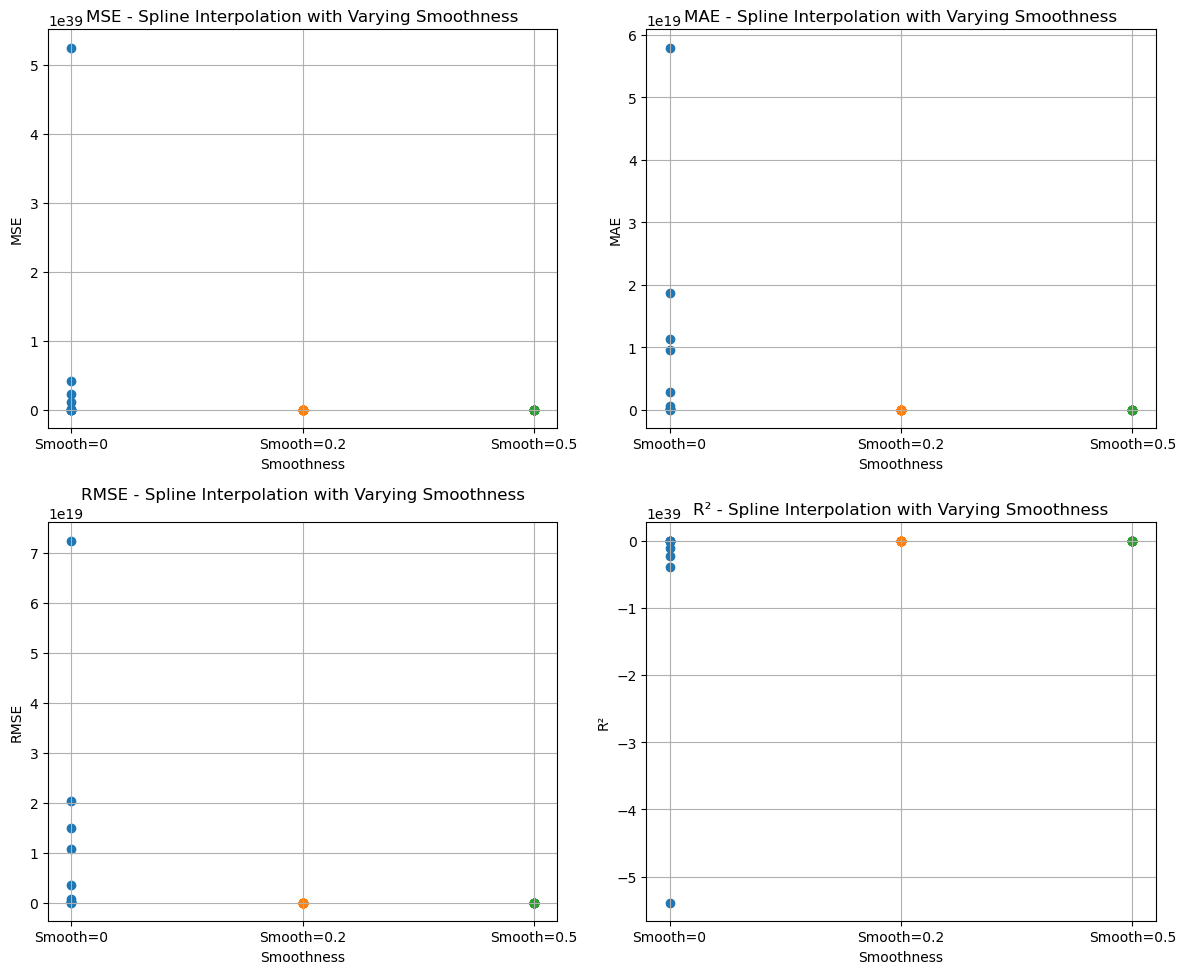


Cross-Validation Results (Average):
              MSE           MAE          RMSE            R²
0.0  6.005349e+38  1.011320e+19  1.227876e+19 -6.123173e+38
0.2  6.060853e-01  6.162939e-01  7.776612e-01  3.855295e-01
0.5  6.208160e-01  6.273813e-01  7.872814e-01  3.716674e-01


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from scipy.interpolate import Rbf
from math import sqrt
import time
import pandas as pd

# Load the data
file_path = '/Users/inayahkhan/Desktop/Group_Diss_Code/'  # Update this path
coords = np.load(file_path + 'coords.npy')
band_powers = np.load(file_path + 'band_powers.npy', allow_pickle=True).item()

# Choose which frequency band to evaluate
band = 'Delta'
values = np.array(band_powers[band])

# ✅ Normalize the input data (to stabilize interpolation)
mean = coords.mean(axis=0)
std = coords.std(axis=0)
coords = (coords - mean) / std
values = (values - np.mean(values)) / np.std(values)

# ✅ Define Spline Interpolation Function
def interpolate_spline(coords, values, new_coords, smoothness, timing=False):
    start_time = time.time()
    interpolator = Rbf(
        coords[:, 0], coords[:, 1], coords[:, 2], values,
        function='multiquadric', smooth=smoothness
    )
    predicted_values = interpolator(
        new_coords[:, 0], new_coords[:, 1], new_coords[:, 2]
    )
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# ✅ Define Metric Calculation Function
def calculate_metrics(pred_values, test_values):
    scores = {
        'MSE': mean_squared_error(test_values, pred_values),
        'MAE': mean_absolute_error(test_values, pred_values),
        'RMSE': sqrt(mean_squared_error(test_values, pred_values)),
        'R²': r2_score(test_values, pred_values)
    }
    return scores

# ✅ Set up cross-validation
num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# ✅ Test smoothness values of 0, 0.2, and 0.5
smoothness_values = [0, 0.2, 0.5]
results = {s: np.zeros((num_folds, 4)) for s in smoothness_values}

# ✅ Cross-validation for each smoothness value
for smoothness in smoothness_values:
    print(f"\nRunning cross-validation for smoothness={smoothness}...")
    for i, (train_index, test_index) in enumerate(kf.split(coords)):
        train_coords, test_coords = coords[train_index], coords[test_index]
        train_values, test_values = values[train_index], values[test_index]
        
        try:
            pred_values, _ = interpolate_spline(train_coords, train_values, test_coords, smoothness, timing=True)
            valid_indices = ~np.isnan(pred_values)
            pred_values = pred_values[valid_indices]
            test_values = test_values[valid_indices]
            
            if len(pred_values) > 0:
                scores = calculate_metrics(pred_values, test_values)
                results[smoothness][i] = [scores[m] for m in ['MSE', 'MAE', 'RMSE', 'R²']]
        except Exception as e:
            print(f"⚠️ Error in fold {i + 1}: {e}")

# ✅ Compute averages
avg_results = {s: results[s].mean(axis=0) for s in smoothness_values}

# ✅ Create a 2x2 grid for scatter plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
metrics = ['MSE', 'MAE', 'RMSE', 'R²']

for i, metric in enumerate(metrics):
    for smoothness in smoothness_values:
        axes[i].scatter(
            [f"Smooth={smoothness}"] * num_folds,
            results[smoothness][:, i],
            label=f"Smooth={smoothness}"
        )
    axes[i].set_title(f"{metric} - Spline Interpolation with Varying Smoothness")
    axes[i].set_xlabel('Smoothness')
    axes[i].set_ylabel(metric)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# ✅ Display average results
print("\nCross-Validation Results (Average):")
df_results = {s: avg_results[s] for s in smoothness_values}
df = pd.DataFrame(df_results, index=metrics).T
print(df)
